# numpy-cnn Demo
A deep learning framework built entirely with NumPy.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
%matplotlib inline
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

from numpyml import *
from numpyml.model import Model

## 1. Activation Functions

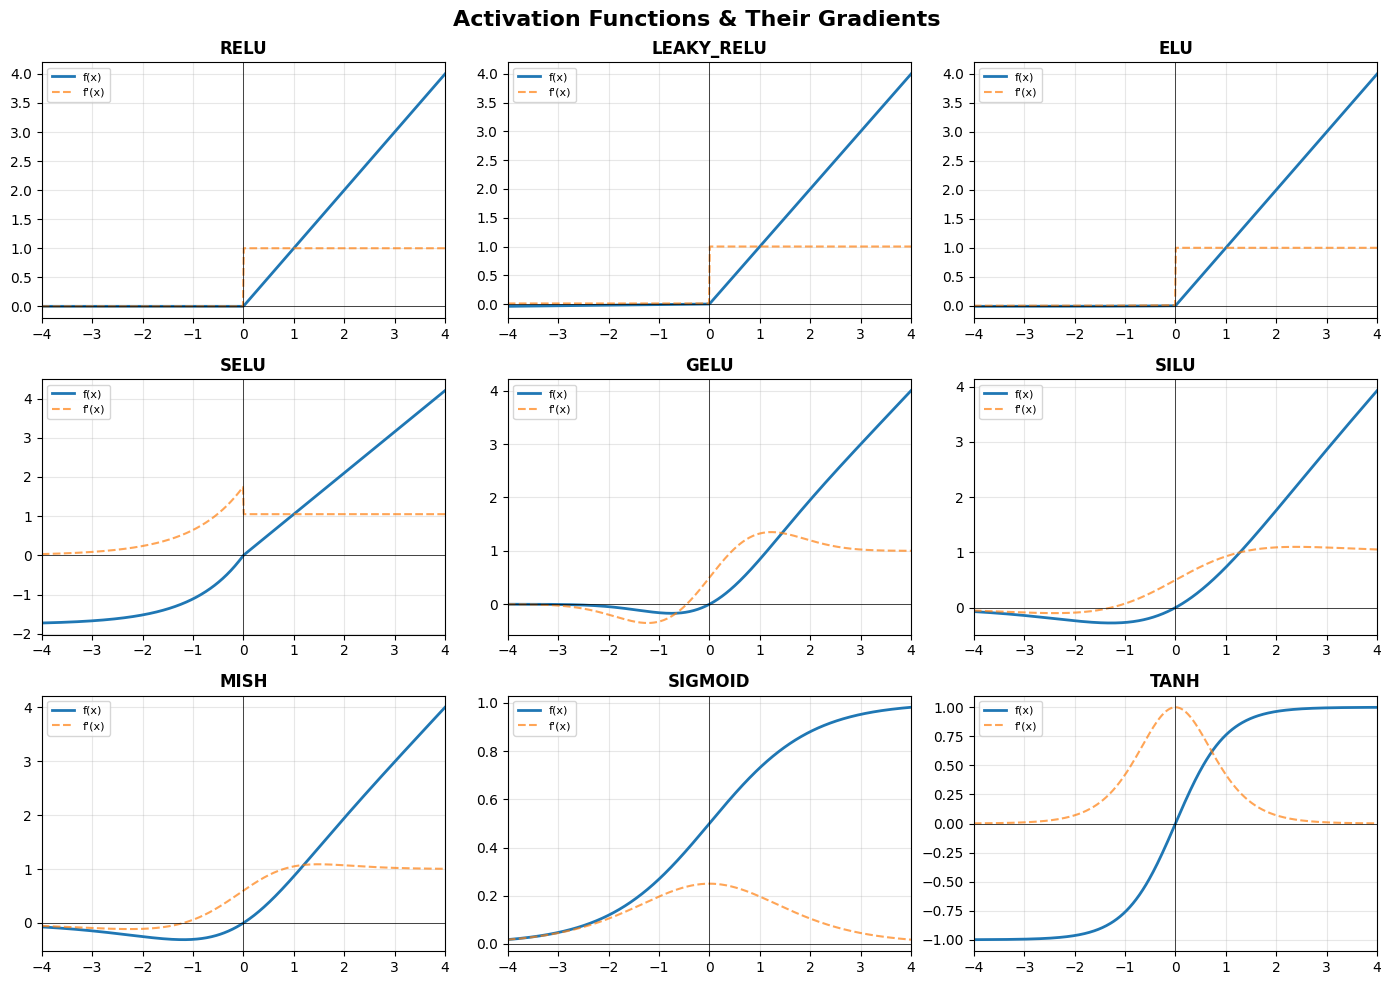

In [2]:
x = np.linspace(-4, 4, 500).reshape(1, -1)
activations = ['relu', 'leaky_relu', 'elu', 'selu', 'gelu', 'silu', 'mish', 'sigmoid', 'tanh']
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
fig.suptitle('Activation Functions & Their Gradients', fontsize=16, fontweight='bold')
for ax, name in zip(axes.ravel(), activations):
    a = Activation(name)
    a.build((None, 500))
    y = a.forward(x.copy())
    dy = a.backward(np.ones_like(y), 0.0)
    ax.plot(x[0], y[0], linewidth=2, label='f(x)')
    ax.plot(x[0], dy[0], linewidth=1.5, linestyle='--', alpha=0.7, label="f'(x)")
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)
    ax.set_title(name.upper(), fontweight='bold')
    ax.set_xlim(-4, 4)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 2. Load Fashion-MNIST

Train: (54000, 28, 28, 1), Val: (6000, 28, 28, 1), Test: (10000, 28, 28, 1)


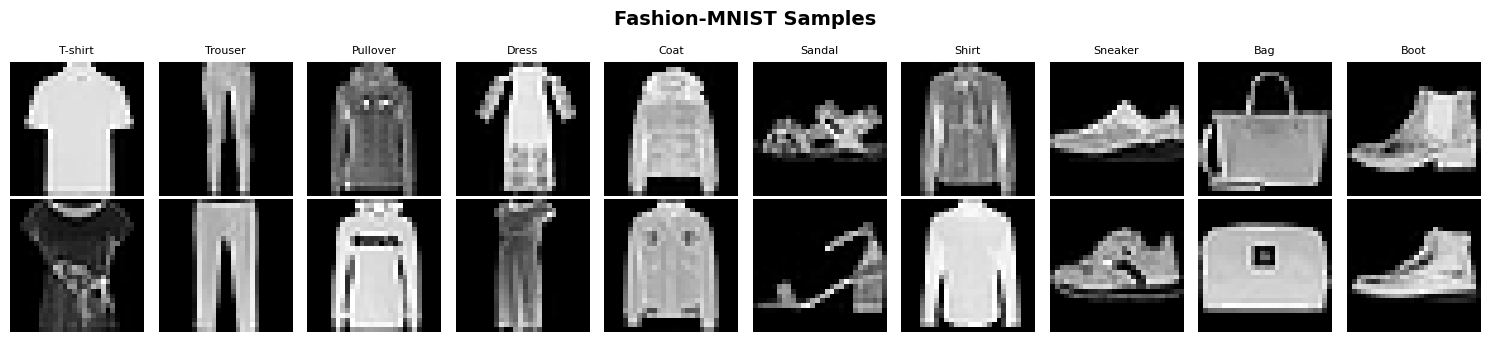

In [3]:
(X_train, y_train_raw), (X_test, y_test_raw) = load_fashion_mnist()
y_train = one_hot(y_train_raw)
y_test = one_hot(y_test_raw)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42)
y_train_raw_split = np.argmax(y_train, axis=1)

CLASS_NAMES = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Boot']

print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')

fig, axes = plt.subplots(2, 10, figsize=(15, 3.5))
fig.suptitle('Fashion-MNIST Samples', fontsize=14, fontweight='bold')
for i in range(10):
    idx = np.where(y_train_raw_split == i)[0][0]
    axes[0, i].imshow(X_train[idx, :, :, 0], cmap='gray')
    axes[0, i].set_title(CLASS_NAMES[i], fontsize=8)
    axes[0, i].axis('off')
    idx2 = np.where(y_train_raw_split == i)[0][1]
    axes[1, i].imshow(X_train[idx2, :, :, 0], cmap='gray')
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()

## 3. Data Augmentation Gallery

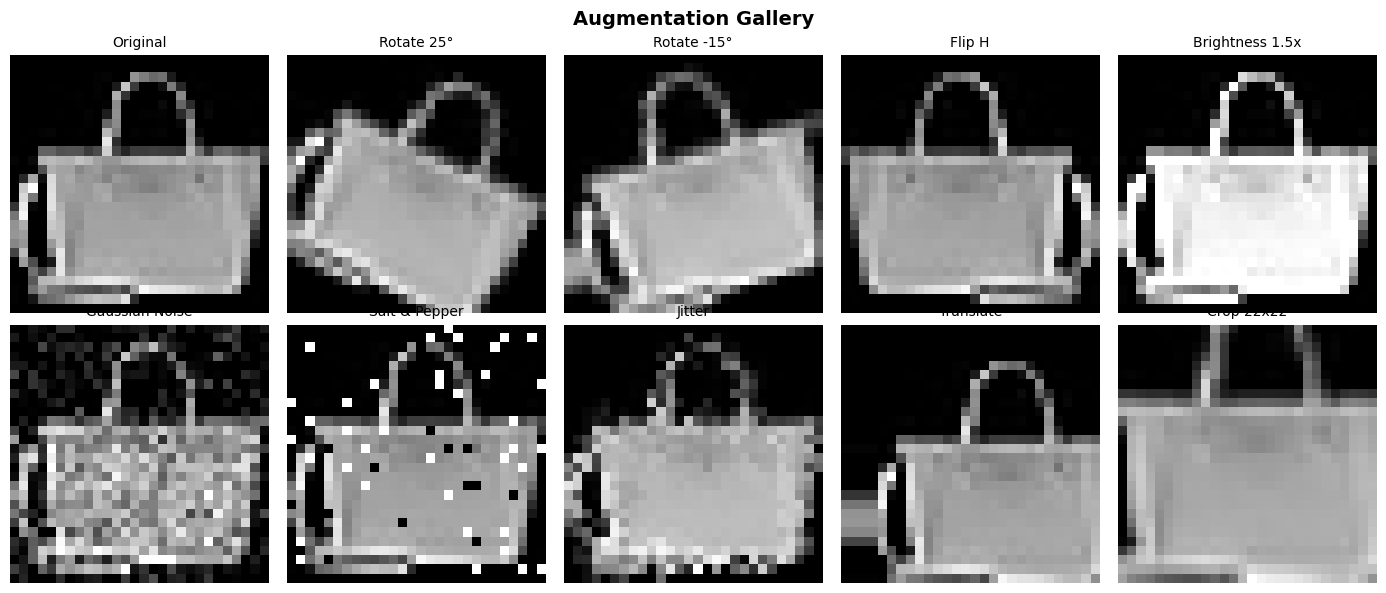

In [4]:
sample = X_train[0]
aug = ImageDataAugmentor()

augmented = {
    'Original': sample,
    'Rotate 25Â°': aug.rotate(sample, 25),
    'Rotate -15Â°': aug.rotate(sample, -15),
    'Flip H': aug.flip(sample, horizontal=True),
    'Brightness 1.5x': aug.adjust_brightness(sample, 1.5),
    'Gaussian Noise': aug.add_gaussian_noise(sample, std=0.15),
    'Salt & Pepper': aug.add_salt_pepper_noise(sample, 0.05, 0.05),
    'Jitter': aug.jitter(sample, sigma=0.5),
    'Translate': aug.translate(sample, 3, 2),
    'Crop 22x22': aug.resize_image(aug.random_crop(sample, (22, 22)), (28, 28)),
}

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Augmentation Gallery', fontsize=14, fontweight='bold')
for ax, (name, img) in zip(axes.ravel(), augmented.items()):
    ax.imshow(np.squeeze(img), cmap='gray')
    ax.set_title(name, fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 4. Build & Train CNN

In [5]:
model = Model()
model.add(Conv2D(32, (5, 5), activation='relu', padding='same'))
model.add(LayerNorm())
model.add(Pooling2D((2, 2), stride=2))
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(LayerNorm())
model.add(Pooling2D((2, 2), stride=2))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.1))
model.add(LayerNorm())
model.add(Dense(64, activation='relu'))
model.add(LayerNorm())
model.add(Dense(10, activation='softmax'))

model.compile((None, 28, 28, 1), Adam(use_agc=True), 'he')
model.summary()

Layer #   OPERATION           DATA DIMENSIONS   WEIGHTS(N)   WEIGHTS(%)   ACTIVATION
0        Convolution2D               28x28x32          832        0.2% RELU
1        LayerNorm                   28x28x32           64        0.0% 
2        Pooling2D                   14x14x32            0        0.0% MAX
3        Convolution2D               14x14x64        18496        4.3% RELU
4        LayerNorm                   14x14x64          128        0.0% 
5        Pooling2D                     7x7x64            0        0.0% MAX
6        Flatten                         3136            0        0.0% 
7        Dense                            128       401536       93.3% RELU
8        Dropout                          128            0        0.0% 
9        LayerNorm                        128          256        0.1% 
10       Dense                             64         8256        1.9% RELU
11       LayerNorm                         64          128        0.0% 
12       Dense               

In [6]:
augmentor = ImageDataAugmentor(augmentations=[
    (lambda self, img: self.add_gaussian_noise(img, std=np.random.uniform(0.01, 0.15)), 0.15),
    (lambda self, img: self.jitter(img, sigma=np.random.uniform(0.1, 0.4)), 0.15),
])

lr_scheduler = CosineAnnealingLR(initial_lr=0.001, T_max=5, min_lr=1e-5)

history = model.fit(
    X_train, y_train, X_val, y_val,
    batch_size=128, epochs=5,
    loss_fn=categorical_crossentropy,
    l2_lambda=0.001,
    lr_scheduler=lr_scheduler,
    augmentor=augmentor,
)


 Epoch 1/5
[========================================>] Batch 422/422 - Loss: 0.4703 - Train Loss: 0.4524 - Train Acc: 0.8377 - Val Loss: 0.2948 - Val Acc: 0.8898

 Epoch 2/5
[========================================>] Batch 422/422 - Loss: 0.3188 - Train Loss: 0.3046 - Train Acc: 0.8892 - Val Loss: 0.2681 - Val Acc: 0.9005

 Epoch 3/5
[========================================>] Batch 422/422 - Loss: 0.1173 - Train Loss: 0.2637 - Train Acc: 0.9020 - Val Loss: 0.2499 - Val Acc: 0.9065

 Epoch 4/5
[========================================>] Batch 422/422 - Loss: 0.1370 - Train Loss: 0.2297 - Train Acc: 0.9152 - Val Loss: 0.2477 - Val Acc: 0.9082

 Epoch 5/5
[========================================>] Batch 422/422 - Loss: 0.1791 - Train Loss: 0.1980 - Train Acc: 0.9267 - Val Loss: 0.2286 - Val Acc: 0.9157


## 5. Training Curves

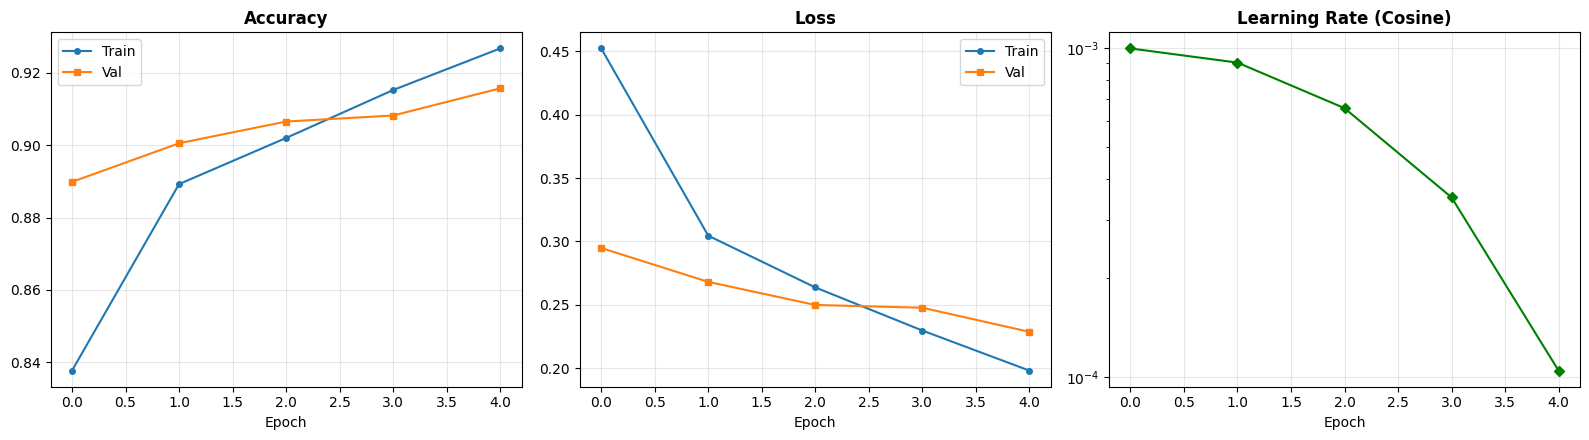

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(history['train_accuracy'], 'o-', label='Train', markersize=4)
axes[0].plot(history['val_accuracy'], 's-', label='Val', markersize=4)
axes[0].set_title('Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history['train_loss'], 'o-', label='Train', markersize=4)
axes[1].plot(history['val_loss'], 's-', label='Val', markersize=4)
axes[1].set_title('Loss', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].legend()

lrs = []
cos_sched = CosineAnnealingLR(initial_lr=0.001, T_max=5, min_lr=1e-5)
for e in range(5):
    lrs.append(cos_sched(e))
axes[2].plot(lrs, 'D-', color='green', markersize=5)
axes[2].set_title('Learning Rate (Cosine)', fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_yscale('log')

plt.tight_layout()
plt.show()

## 6. Evaluation & Confusion Matrix

In [8]:
test_preds = np.concatenate([model.predict(X_test[i*256:(i+1)*256])
    for i in range(int(np.ceil(len(X_test)/256)))], axis=0)
test_acc = accuracy(y_test, test_preds)
print(f'Test Accuracy: {test_acc:.4f}')
print()
classification_report(y_test, test_preds, class_names=CLASS_NAMES)

Test Accuracy: 0.9096

Class         Precision     Recall         F1    Support
------------------------------------------------------
T-shirt          0.8355     0.8990     0.8661       1000
Trouser          0.9889     0.9840     0.9865       1000
Pullover         0.8229     0.8690     0.8453       1000
Dress            0.9173     0.9100     0.9137       1000
Coat             0.8147     0.8750     0.8438       1000
Sandal           0.9782     0.9880     0.9831       1000
Shirt            0.8186     0.6590     0.7302       1000
Sneaker          0.9530     0.9740     0.9634       1000
Bag              0.9860     0.9830     0.9845       1000
Boot             0.9815     0.9550     0.9681       1000
------------------------------------------------------
Macro avg        0.9097     0.9096     0.9085      10000
Accuracy                               0.9096      10000


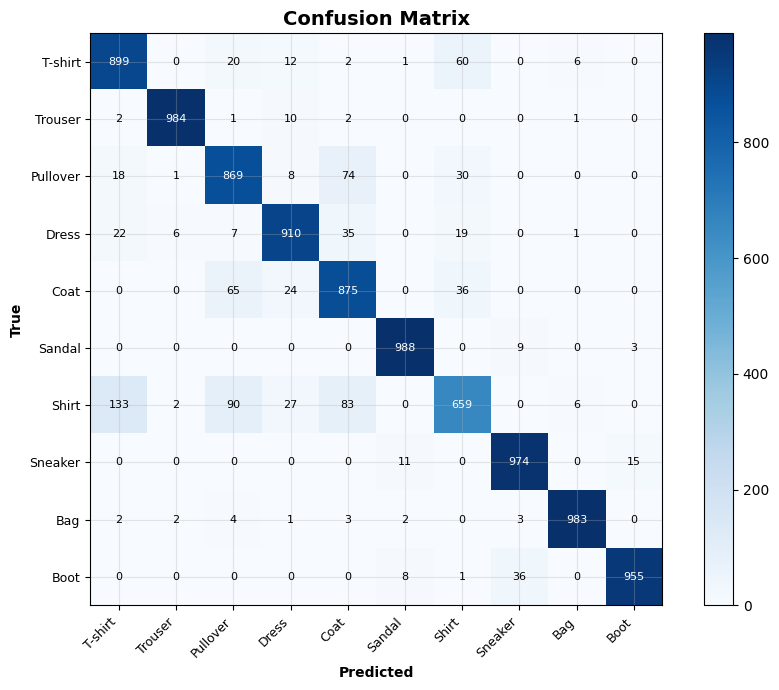

In [9]:
cm = confusion_matrix(y_test, test_preds)
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(CLASS_NAMES, fontsize=9)
for i in range(10):
    for j in range(10):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', color=color, fontsize=8)
ax.set_xlabel('Predicted', fontweight='bold')
ax.set_ylabel('True', fontweight='bold')
ax.set_title('Confusion Matrix', fontweight='bold', fontsize=14)
fig.colorbar(im, fraction=0.046)
plt.tight_layout()
plt.show()

## 7. Conv Layer Feature Maps

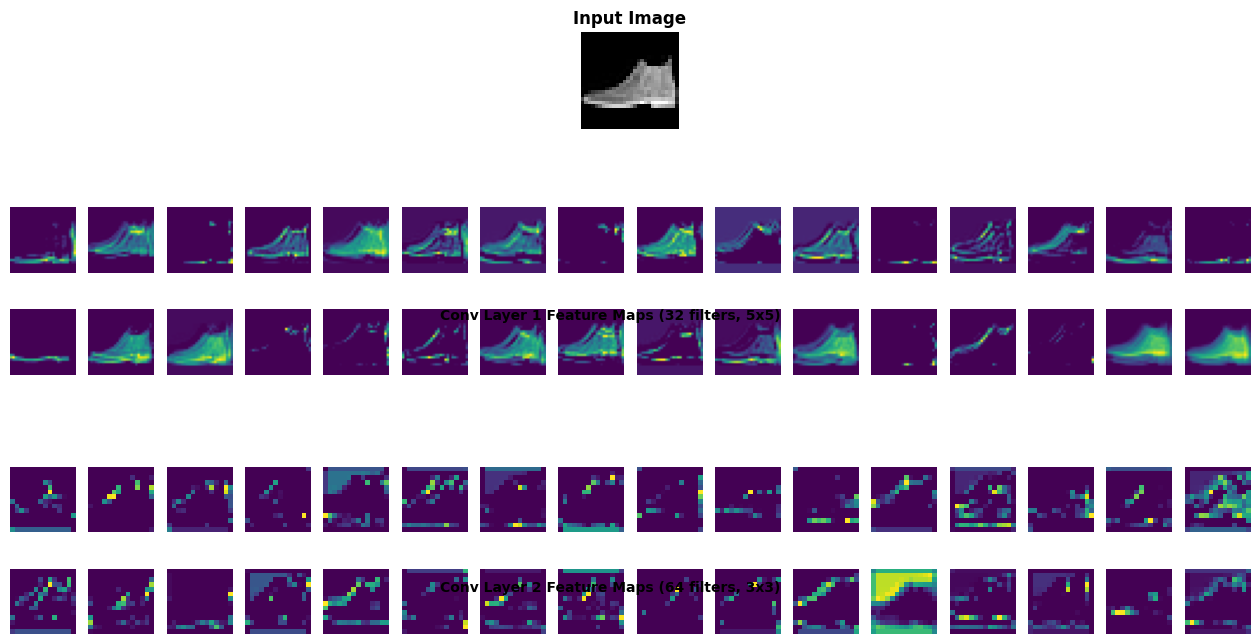

In [10]:
sample_img = X_test[0:1]

conv1_out = model.forward(sample_img, training=False, return_layer=0)
conv2_out = model.forward(sample_img, training=False, return_layer=3)

fig = plt.figure(figsize=(16, 8))
gs = GridSpec(3, 1, height_ratios=[1, 2, 2], hspace=0.4)

ax0 = fig.add_subplot(gs[0])
ax0.imshow(sample_img[0, :, :, 0], cmap='gray')
ax0.set_title('Input Image', fontweight='bold')
ax0.axis('off')

gs1 = gs[1].subgridspec(2, 16, hspace=0.1)
for i in range(min(32, conv1_out.shape[-1])):
    ax = fig.add_subplot(gs1[i // 16, i % 16])
    ax.imshow(conv1_out[0, :, :, i], cmap='viridis')
    ax.axis('off')
fig.text(0.5, 0.52, 'Conv Layer 1 Feature Maps (32 filters, 5x5)', ha='center', fontweight='bold')

gs2 = gs[2].subgridspec(2, 16, hspace=0.1)
for i in range(min(32, conv2_out.shape[-1])):
    ax = fig.add_subplot(gs2[i // 16, i % 16])
    ax.imshow(conv2_out[0, :, :, i], cmap='viridis')
    ax.axis('off')
fig.text(0.5, 0.18, 'Conv Layer 2 Feature Maps (64 filters, 3x3)', ha='center', fontweight='bold')

plt.show()

## 8. Learned Conv Kernels

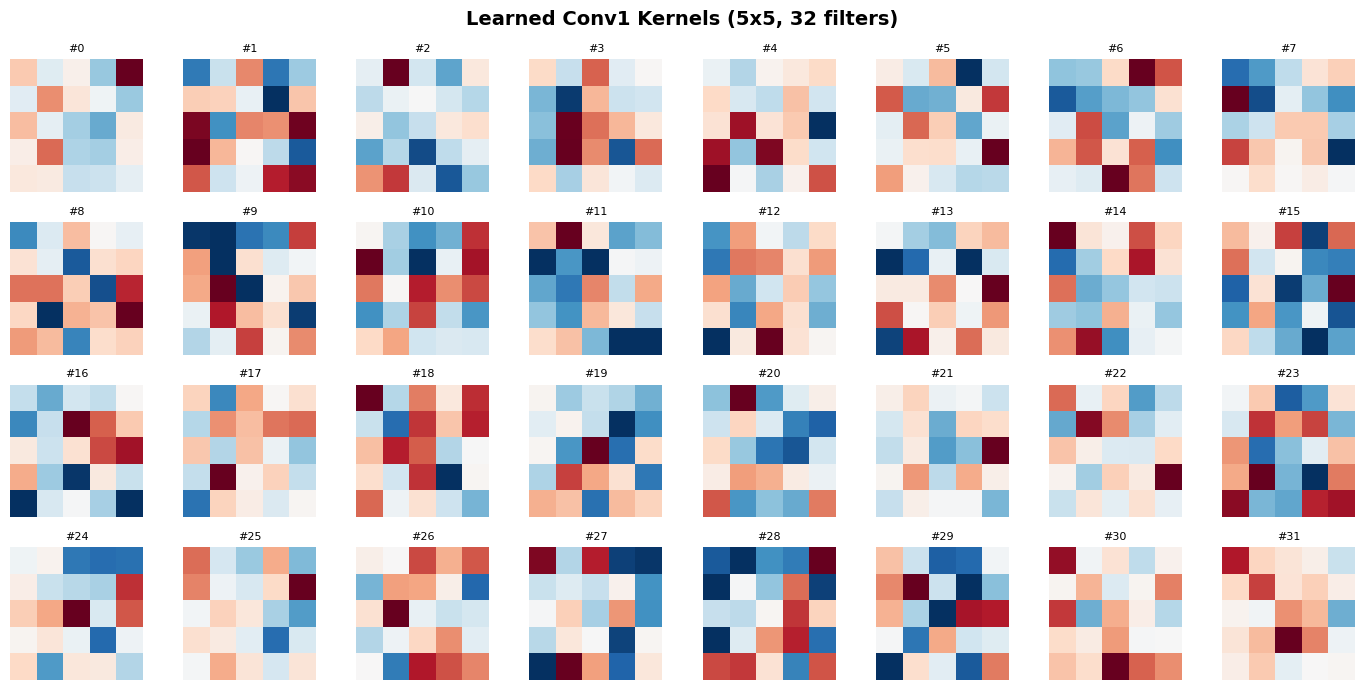

In [11]:
W = model.layers[0].params['W']
fig, axes = plt.subplots(4, 8, figsize=(14, 7))
fig.suptitle(f'Learned Conv1 Kernels ({W.shape[0]}x{W.shape[1]}, {W.shape[3]} filters)', fontsize=14, fontweight='bold')
for i, ax in enumerate(axes.ravel()):
    if i < W.shape[3]:
        kernel = W[:, :, 0, i]
        ax.imshow(kernel, cmap='RdBu_r', vmin=-kernel.max(), vmax=kernel.max())
        ax.set_title(f'#{i}', fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 9. Prediction Confidence

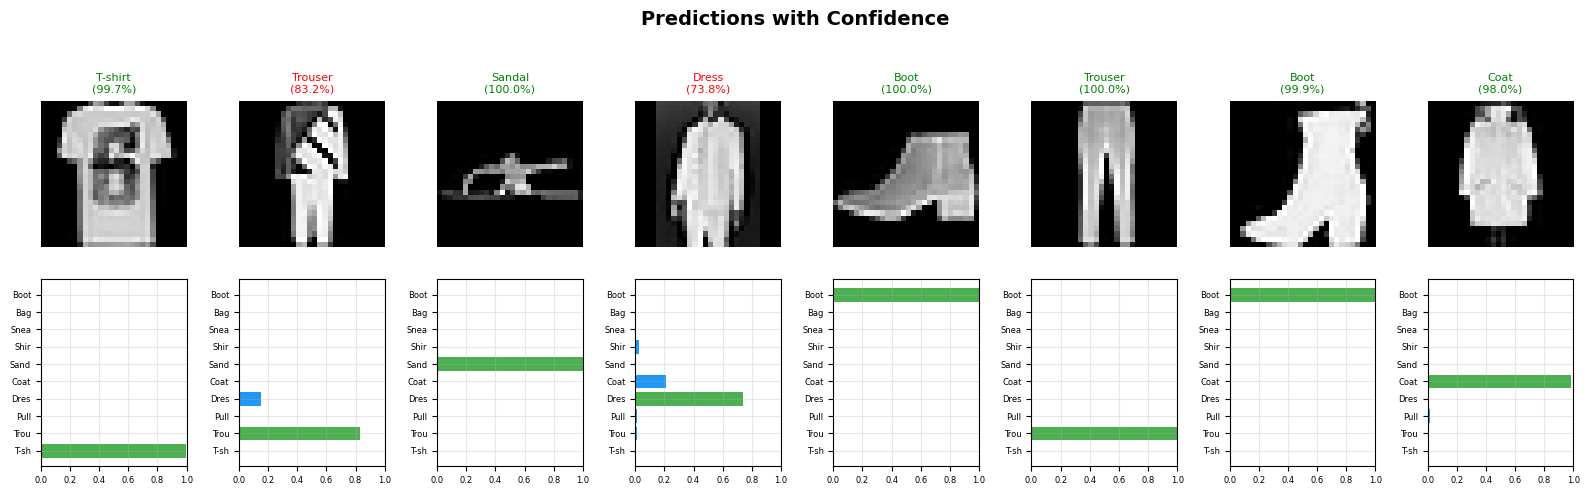

In [12]:
np.random.seed(7)
indices = np.random.choice(len(X_test), 8, replace=False)
samples = X_test[indices]
preds = model.predict(samples)
true_labels = np.argmax(y_test[indices], axis=1)

fig, axes = plt.subplots(2, 8, figsize=(16, 5), gridspec_kw={'height_ratios': [2, 1.5]})
fig.suptitle('Predictions with Confidence', fontsize=14, fontweight='bold')
for i in range(8):
    axes[0, i].imshow(samples[i, :, :, 0], cmap='gray')
    pred_class = np.argmax(preds[i])
    color = 'green' if pred_class == true_labels[i] else 'red'
    axes[0, i].set_title(f'{CLASS_NAMES[pred_class]}\n({preds[i, pred_class]:.1%})', fontsize=8, color=color)
    axes[0, i].axis('off')
    bars = axes[1, i].barh(range(10), preds[i], color=['#2196F3' if j != pred_class else '#4CAF50' for j in range(10)])
    axes[1, i].set_xlim(0, 1)
    axes[1, i].set_yticks(range(10))
    axes[1, i].set_yticklabels([n[:4] for n in CLASS_NAMES], fontsize=6)
    axes[1, i].tick_params(axis='x', labelsize=6)
plt.tight_layout()
plt.show()

## 10. Optimizer Comparison on Rosenbrock

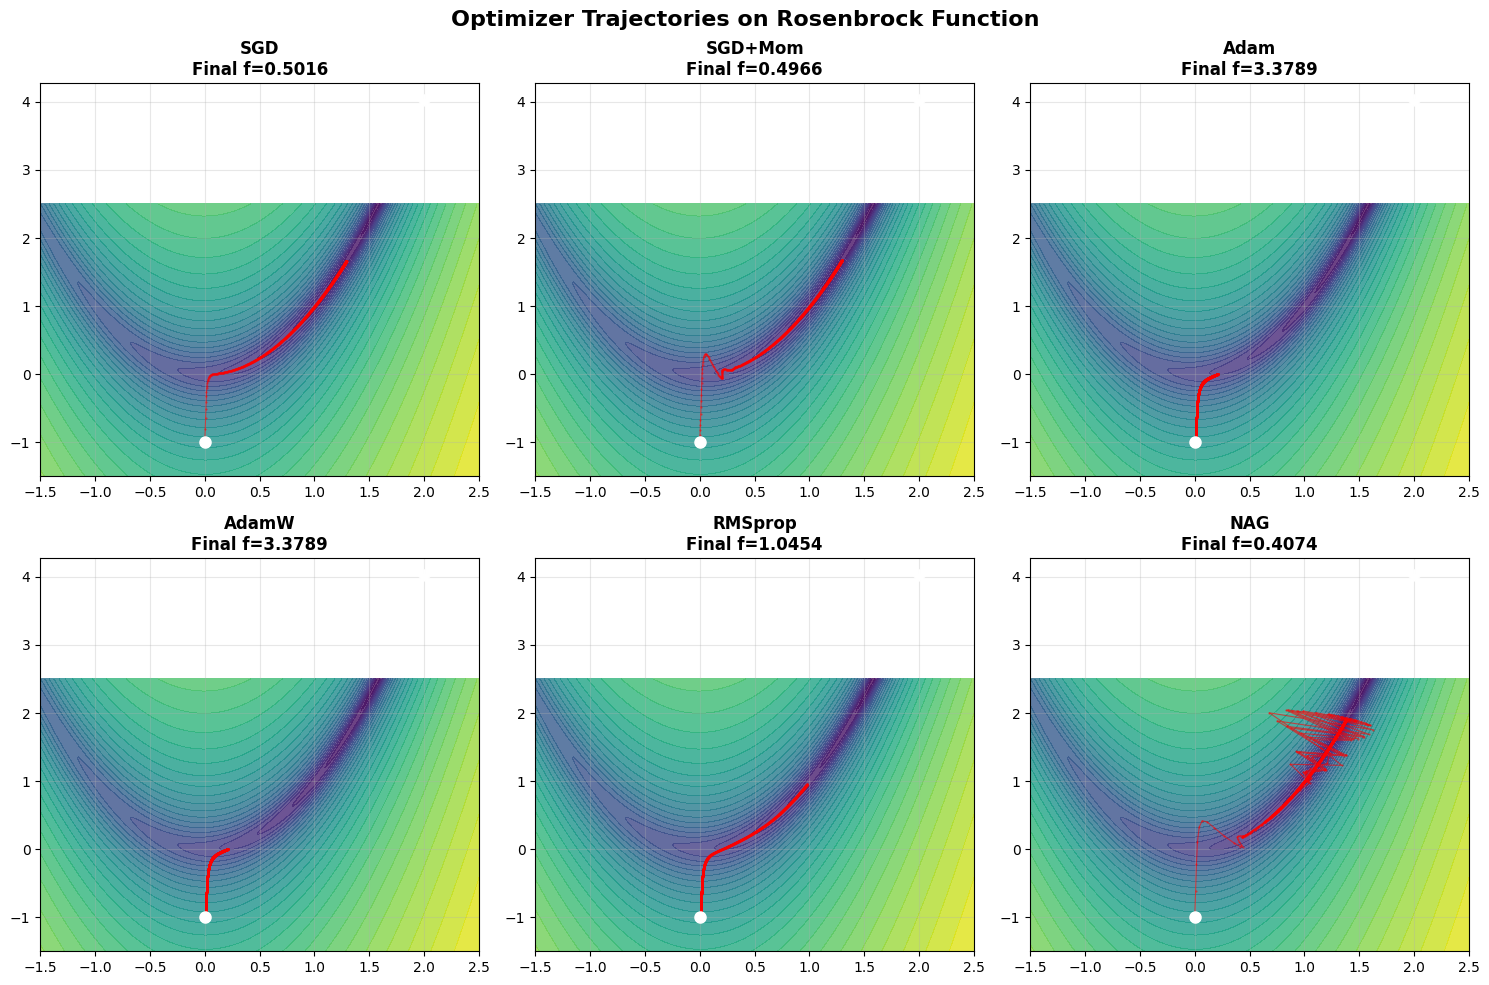

In [13]:
from numpyml.layers import BaseLayer

def rosenbrock(x, y, a=2, b=100):
    return (a - x)**2 + b*(y - x**2)**2

def rosenbrock_grad(x, y, a=2, b=100):
    return {"dx": -2*(a - x) - 4*b*x*(y - x**2), "dy": 2*b*(y - x**2)}

class Point(BaseLayer):
    def __init__(self):
        super().__init__()
        self.params = {"x": np.array([0.0]), "y": np.array([-1.0])}

opts = {
    'SGD': SGD(), 'SGD+Mom': SGDmom(), 'Adam': Adam(),
    'AdamW': AdamW(), 'RMSprop': RMSprop(), 'NAG': NAG(),
}

x_grid = np.linspace(-1.5, 2.5, 300)
y_grid = np.linspace(-1.5, 2.5, 300)
X_g, Y_g = np.meshgrid(x_grid, y_grid)
Z_g = rosenbrock(X_g, Y_g)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Optimizer Trajectories on Rosenbrock Function', fontsize=16, fontweight='bold')

for ax, (name, opt) in zip(axes.ravel(), opts.items()):
    layer = Point()
    opt.init_params(layer)
    path = []
    for _ in range(2000):
        x, y = layer.params['x'], layer.params['y']
        path.append((x[0], y[0]))
        grads = rosenbrock_grad(x, y)
        opt.update(layer, grads, 0.001)
    path = np.array(path)
    ax.contourf(X_g, Y_g, np.log1p(Z_g), 30, cmap='viridis', alpha=0.8)
    ax.plot(path[:, 0], path[:, 1], 'r.-', markersize=1, linewidth=0.8, alpha=0.6)
    ax.plot(2, 4, 'w*', markersize=12)
    ax.plot(path[0, 0], path[0, 1], 'wo', markersize=8)
    final_val = rosenbrock(path[-1, 0], path[-1, 1])
    ax.set_title(f'{name}\nFinal f={final_val:.4f}', fontweight='bold')
plt.tight_layout()
plt.show()

## 11. LR Scheduler Comparison

Learning rate scheduler: new_lr = 0.005, current_lr = 0.01
Learning rate scheduler: new_lr = 0.0025, current_lr = 0.005
Learning rate scheduler: new_lr = 0.00125, current_lr = 0.0025
Learning rate scheduler: new_lr = 0.000625, current_lr = 0.00125
Learning rate scheduler: new_lr = 0.0003125, current_lr = 0.000625


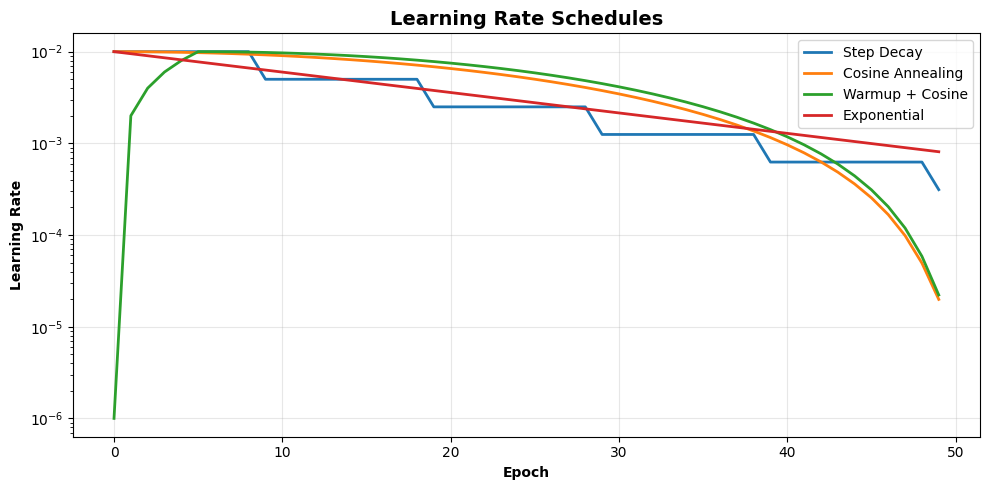

In [14]:
epochs = 50
schedulers = {
    'Step Decay': LRScheduler(0.01, lr_decay_factor=0.5, step_size=10, patient=False),
    'Cosine Annealing': CosineAnnealingLR(0.01, T_max=epochs, min_lr=1e-5),
    'Warmup + Cosine': WarmupScheduler(CosineAnnealingLR(0.01, T_max=epochs-5, min_lr=1e-5), warmup_epochs=5, warmup_start_lr=1e-6),
    'Exponential': ExponentialLR(0.01, decay_rate=0.95),
}

fig, ax = plt.subplots(figsize=(10, 5))
for name, sched in schedulers.items():
    lrs = [sched(e, val_loss=1.0) for e in range(epochs)]
    ax.plot(lrs, linewidth=2, label=name)
ax.set_xlabel('Epoch', fontweight='bold')
ax.set_ylabel('Learning Rate', fontweight='bold')
ax.set_title('Learning Rate Schedules', fontsize=14, fontweight='bold')
ax.legend()
ax.set_yscale('log')
plt.tight_layout()
plt.show()

## 12. Normalization Comparison

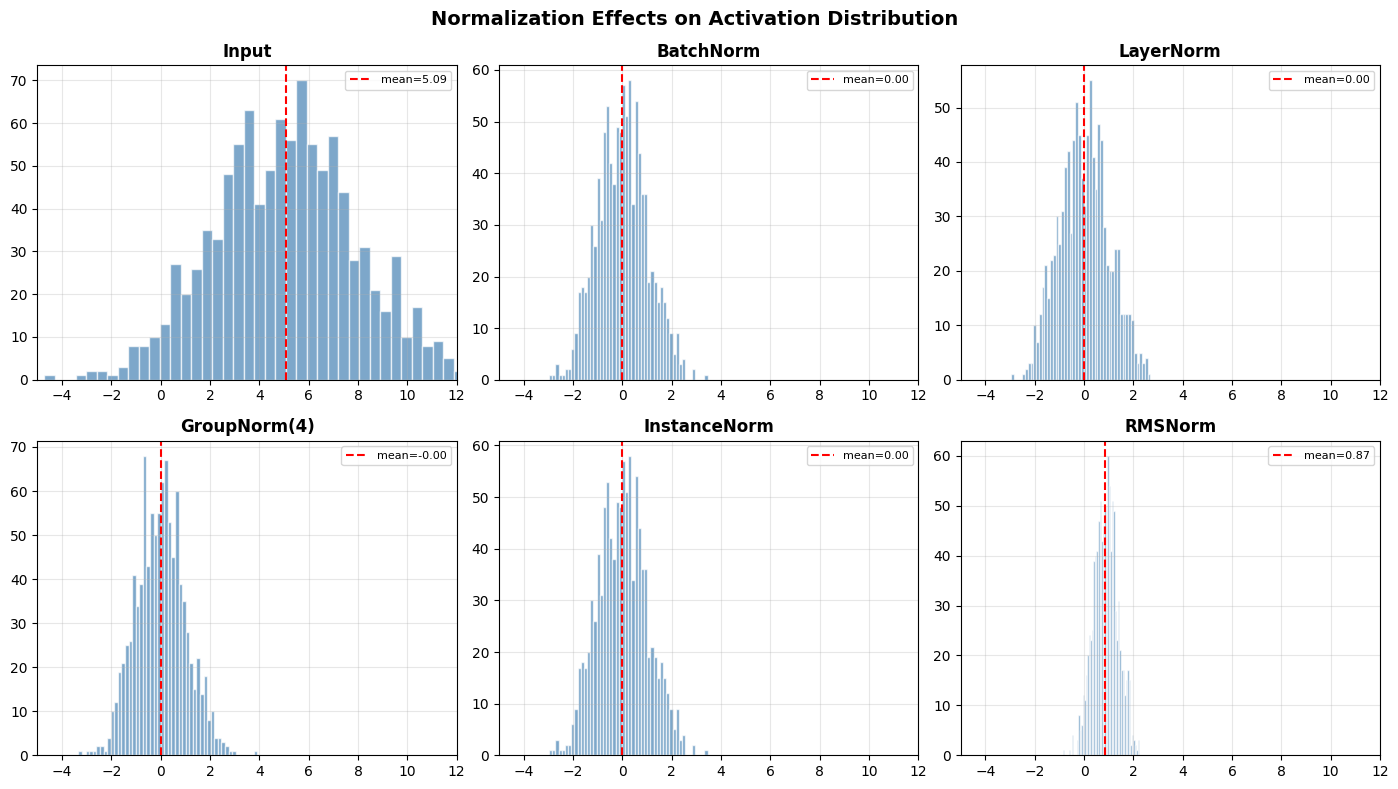

In [15]:
np.random.seed(42)
x_raw = np.random.randn(1, 8, 8, 16) * 3 + 5

norms = {
    'Input': x_raw,
    'BatchNorm': None, 'LayerNorm': None, 'GroupNorm(4)': None,
    'InstanceNorm': None, 'RMSNorm': None,
}

bn = BatchNorm(); bn.build((None, 8, 8, 16)); norms['BatchNorm'] = bn.forward(x_raw.copy())
ln = LayerNorm(); ln.build((None, 8, 8, 16)); norms['LayerNorm'] = ln.forward(x_raw.copy())
gn = GroupNorm(4); gn.build((None, 8, 8, 16)); norms['GroupNorm(4)'] = gn.forward(x_raw.copy())
inn = InstanceNorm(); inn.build((None, 8, 8, 16)); norms['InstanceNorm'] = inn.forward(x_raw.copy())
rn = RMSNorm(); rn.build((None, 8, 8, 16)); norms['RMSNorm'] = rn.forward(x_raw.copy())

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Normalization Effects on Activation Distribution', fontsize=14, fontweight='bold')
for ax, (name, data) in zip(axes.ravel(), norms.items()):
    ax.hist(data.ravel(), bins=50, alpha=0.7, color='steelblue', edgecolor='white')
    ax.axvline(data.mean(), color='red', linestyle='--', label=f'mean={data.mean():.2f}')
    ax.set_title(name, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_xlim(-5, 12)
plt.tight_layout()
plt.show()

## 13. Pooling Visualization

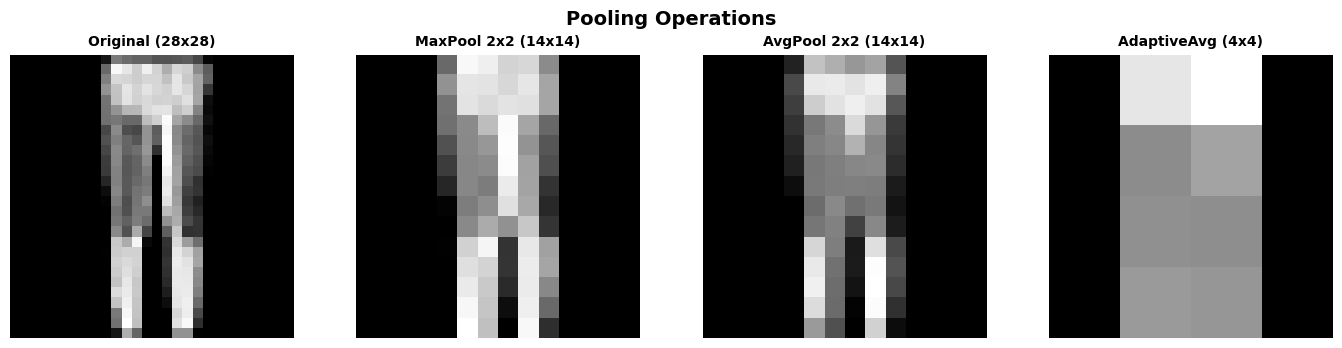

In [16]:
test_img = X_test[3:4]
mp = Pooling2D((2, 2), 2, 'max'); mp.build((None, 28, 28, 1))
ap = Pooling2D((2, 2), 2, 'average'); ap.build((None, 28, 28, 1))
gap = AdaptiveAvgPool2D((4, 4)); gap.build((None, 28, 28, 1))

max_out = mp.forward(test_img)
avg_out = ap.forward(test_img)
adp_out = gap.forward(test_img)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
titles = ['Original (28x28)', 'MaxPool 2x2 (14x14)', 'AvgPool 2x2 (14x14)', 'AdaptiveAvg (4x4)']
images = [test_img[0,:,:,0], max_out[0,:,:,0], avg_out[0,:,:,0], adp_out[0,:,:,0]]
for ax, title, img in zip(axes, titles, images):
    ax.imshow(img, cmap='gray')
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.axis('off')
fig.suptitle('Pooling Operations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 14. Upsample & ConvTranspose

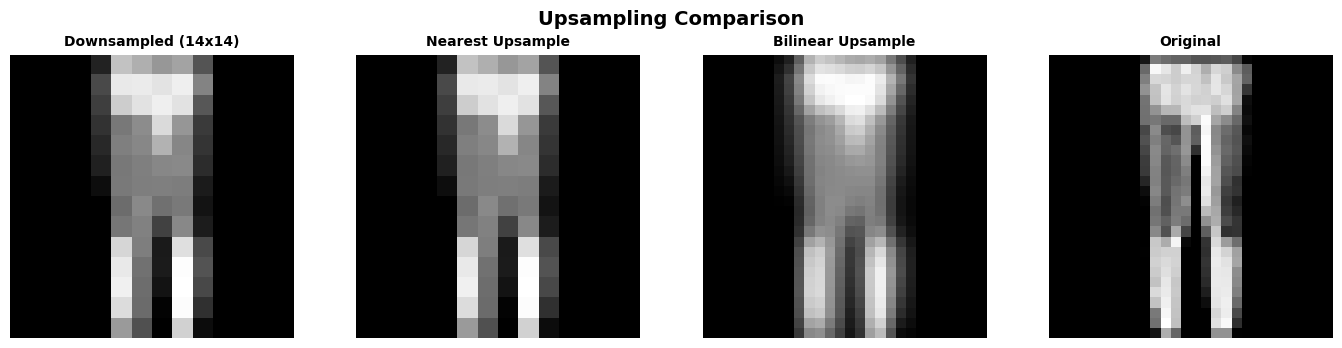

In [17]:
small = avg_out
nn_up = Upsample2D(2, 'nearest'); nn_up.build((None, 14, 14, 1))
bi_up = Upsample2D(2, 'bilinear'); bi_up.build((None, 14, 14, 1))

nn_out = nn_up.forward(small)
bi_out = bi_up.forward(small)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
titles = ['Downsampled (14x14)', 'Nearest Upsample', 'Bilinear Upsample', 'Original']
images = [small[0,:,:,0], nn_out[0,:,:,0], bi_out[0,:,:,0], test_img[0,:,:,0]]
for ax, title, img in zip(axes, titles, images):
    ax.imshow(img, cmap='gray')
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.axis('off')
fig.suptitle('Upsampling Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 15. Attention Visualization

C:\Users\plivd\AppData\Local\Temp\ipykernel_36788\3189530286.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


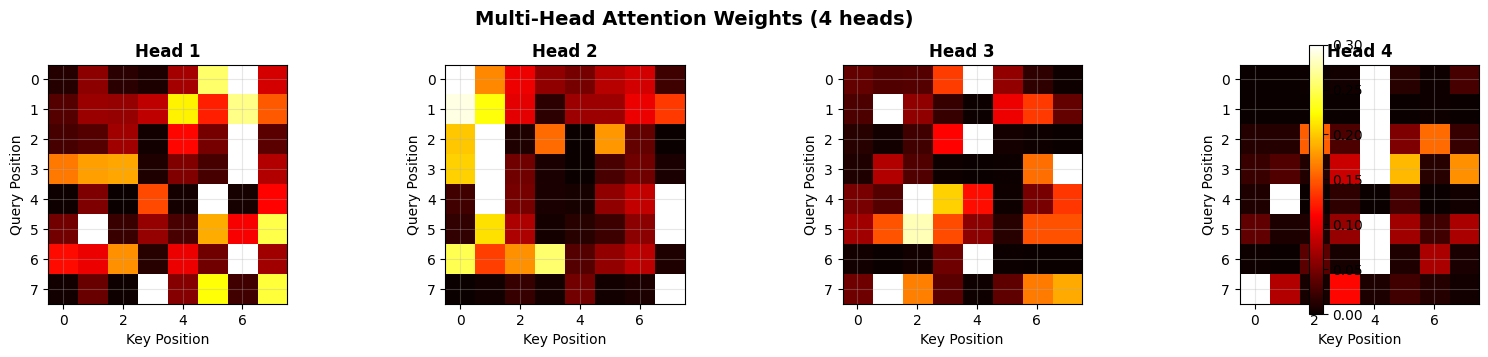

C:\Users\plivd\AppData\Local\Temp\ipykernel_36788\3189530286.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


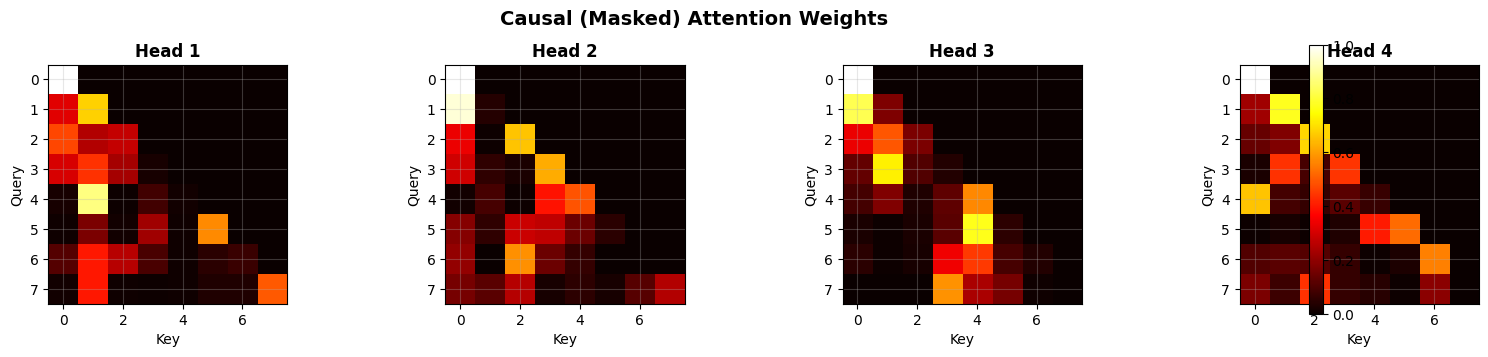

In [18]:
np.random.seed(42)
mha = MultiHeadAttention(d_model=16, num_heads=4)
mha.build((None, 8, 16))
seq = np.random.randn(1, 8, 16)
mha.forward(seq)

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
fig.suptitle('Multi-Head Attention Weights (4 heads)', fontsize=14, fontweight='bold')
for h in range(4):
    im = axes[h].imshow(mha.attn_weights[0, h], cmap='hot', vmin=0, vmax=0.3)
    axes[h].set_title(f'Head {h+1}', fontweight='bold')
    axes[h].set_xlabel('Key Position')
    axes[h].set_ylabel('Query Position')
fig.colorbar(im, ax=axes, fraction=0.02)
plt.tight_layout()
plt.show()

# Causal mask
causal = CausalMultiHeadAttention(d_model=16, num_heads=4)
causal.build((None, 8, 16))
causal.forward(seq)

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
fig.suptitle('Causal (Masked) Attention Weights', fontsize=14, fontweight='bold')
for h in range(4):
    im = axes[h].imshow(causal.attn_weights[0, h], cmap='hot', vmin=0)
    axes[h].set_title(f'Head {h+1}', fontweight='bold')
    axes[h].set_xlabel('Key')
    axes[h].set_ylabel('Query')
fig.colorbar(im, ax=axes, fraction=0.02)
plt.tight_layout()
plt.show()

## 16. Dropout & Regularization Visualization

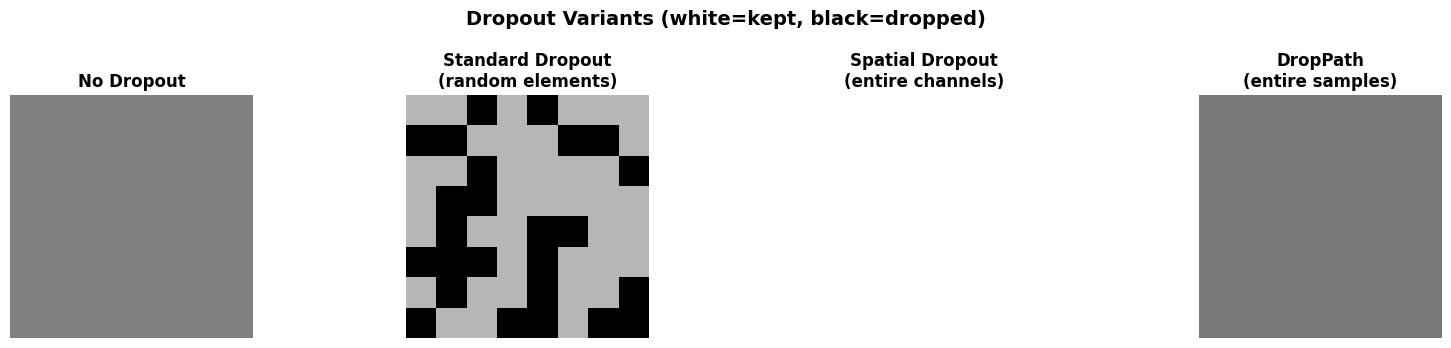

In [19]:
np.random.seed(42)
x_ones = np.ones((1, 8, 8, 16))

reg_drop = Dropout(0.3); reg_drop.build((None, 8, 8, 16))
sp_drop = SpatialDropout(0.3); sp_drop.build((None, 8, 8, 16))
dp = DropPath(0.5); dp.build((None, 8, 8, 16))

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
fig.suptitle('Dropout Variants (white=kept, black=dropped)', fontsize=14, fontweight='bold')

axes[0].imshow(x_ones[0, :, :, 0], cmap='gray', vmin=0, vmax=2)
axes[0].set_title('No Dropout', fontweight='bold')
axes[0].axis('off')

out1 = reg_drop.forward(x_ones.copy(), training=True)
axes[1].imshow(out1[0, :, :, 0], cmap='gray', vmin=0, vmax=2)
axes[1].set_title('Standard Dropout\n(random elements)', fontweight='bold')
axes[1].axis('off')

out2 = sp_drop.forward(x_ones.copy(), training=True)
axes[2].imshow((out2[0, :, :, :4] > 0).astype(float).mean(axis=-1), cmap='gray', vmin=0, vmax=1)
axes[2].set_title('Spatial Dropout\n(entire channels)', fontweight='bold')
axes[2].axis('off')

np.random.seed(0)
drop_vis = np.zeros((8, 8))
for trial in range(64):
    out3 = dp.forward(x_ones.copy(), training=True)
    if np.all(out3 == 0):
        drop_vis += 1
axes[3].imshow(1 - drop_vis / 64, cmap='gray', vmin=0, vmax=1)
axes[3].set_title(f'DropPath\n(entire samples)', fontweight='bold')
axes[3].axis('off')

plt.tight_layout()
plt.show()

## 17. Misclassified Examples

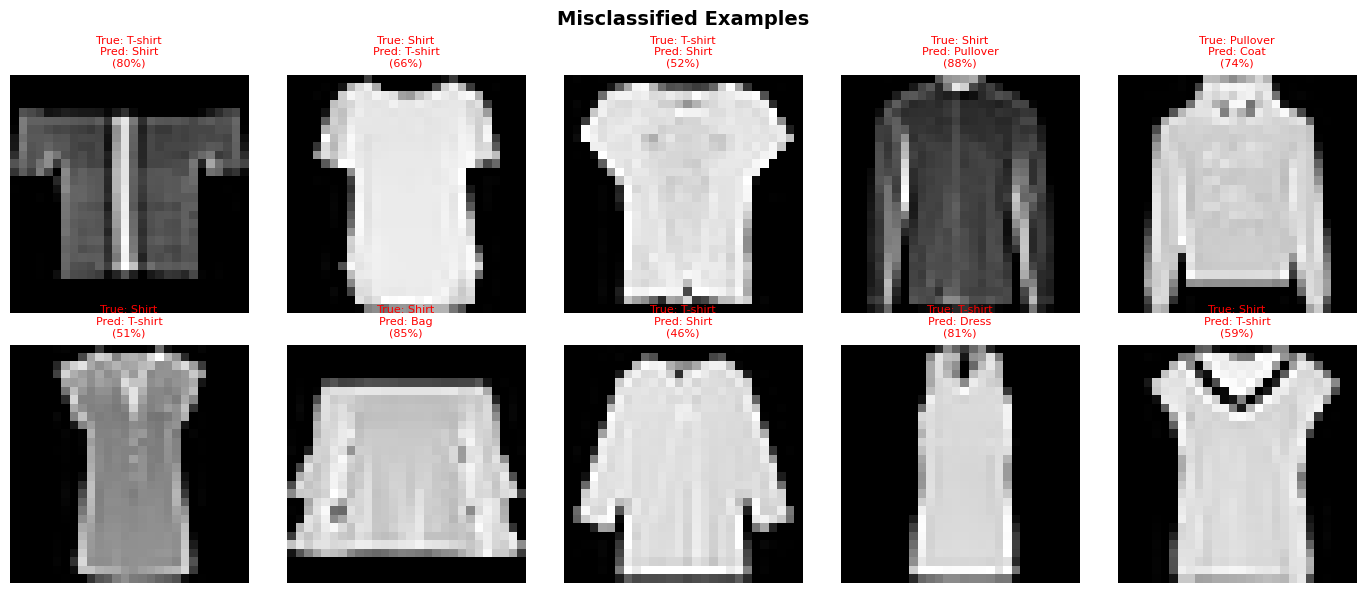

In [20]:
pred_labels = np.argmax(test_preds, axis=1)
true_labels = np.argmax(y_test, axis=1)
wrong = np.where(pred_labels != true_labels)[0]
np.random.seed(42)
wrong_sample = np.random.choice(wrong, min(10, len(wrong)), replace=False)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Misclassified Examples', fontsize=14, fontweight='bold')
for i, idx in enumerate(wrong_sample):
    ax = axes[i // 5, i % 5]
    ax.imshow(X_test[idx, :, :, 0], cmap='gray')
    ax.set_title(f'True: {CLASS_NAMES[true_labels[idx]]}\nPred: {CLASS_NAMES[pred_labels[idx]]}\n({test_preds[idx, pred_labels[idx]]:.0%})',
                fontsize=8, color='red')
    ax.axis('off')
plt.tight_layout()
plt.show()